##### -----------------------------------------------------------
##### CIFAR-10 Experiment: Static vs Adaptive NdLinear Comparison
##### -----------------------------------------------------------
##### Objective:
##### Evaluate the performance difference between:
##### 1. Static NdLinear (fixed axis transformation)
##### 2. Adaptive NdLinear (learned fusion of multiple axis orders)
##### on the CIFAR-10 image classification task.
##### -----------------------------------------------------------

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# -----------------------------------------------------------
# Static NdLinear (baseline): Applies two-stage linear transformation
# -----------------------------------------------------------
class StaticNdLinear(nn.Module):
    def __init__(self, in_dims, out_dims, num_classes=10):
        super().__init__()
        D1, D2 = in_dims
        H1, H2 = out_dims
        self.H1, self.H2 = H1, H2

        self.lin1 = nn.Linear(D1, H1)
        self.lin2 = nn.Linear(D2, H2)

        # Optional final classifier layer
        self.classifier = nn.Linear(H1 * H2, num_classes) if num_classes is not None else None

    def forward(self, x):
        B, D1, D2 = x.shape
        # Step 1: Axis-1 transformation
        y = x.permute(0, 2, 1).reshape(B * D2, D1)
        y = self.lin1(y).view(B, D2, self.H1).permute(0, 2, 1)

        # Step 2: Axis-2 transformation
        y = y.reshape(B * self.H1, D2)
        y = self.lin2(y).view(B, -1)

        return self.classifier(y) if self.classifier else y

# -----------------------------------------------------------
# Adaptive NdLinear: Learns a weighted fusion of two axis orders
# -----------------------------------------------------------
class AdaptiveNdLinearSimple(nn.Module):
    def __init__(self, in_dims, out_dims, num_classes=10):
        super().__init__()

        # Branch A: Original axis order
        self.branchA = StaticNdLinear(in_dims, out_dims, num_classes=None)
        # Branch B: Swapped axis order (D2, D1)
        self.branchB = StaticNdLinear(in_dims[::-1], out_dims[::-1], num_classes=None)

        feat_dim = out_dims[0] * out_dims[1]
        flat_dim = in_dims[0] * in_dims[1]

        # Gating MLP to determine the importance of each branch
        self.gate = nn.Sequential(
            nn.Linear(flat_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=-1)
        )

        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        flat = x.reshape(B, -1)        # Flatten input for gate
        w    = self.gate(flat)         # (B, 2): gate weights

        # Compute features from both branches
        fA = self.branchA(x)
        fB = self.branchB(x.permute(0, 2, 1))

        # Weighted fusion of both views
        fused = w[:, :1] * fA + w[:, 1:] * fB
        return self.classifier(fused)

# -----------------------------------------------------------
# Training utility
# -----------------------------------------------------------
def train_model(model, loader, epochs=10, device='cpu'):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    accs = []

    for ep in range(1, epochs+1):
        total_correct = total = 0
        model.train()
        for xb, yb in loader:
            xb = xb.permute(0, 2, 3, 1).reshape(xb.size(0), 32, -1).to(device)  # Reshape: (B, 32, 96)
            yb = yb.to(device)

            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

            total_correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)

        acc = total_correct / total * 100
        accs.append(acc)
        print(f"[{model.__class__.__name__}] Epoch {ep:2d} — Acc: {acc:5.2f}%")

    return accs

# -----------------------------------------------------------
# Main experiment runner: Compare static vs adaptive
# -----------------------------------------------------------
def main():
    # CIFAR-10 dataset setup
    transform = transforms.Compose([transforms.ToTensor()])
    ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader = DataLoader(ds, batch_size=64, shuffle=True)

    in_dims  = (32, 32 * 3)  # Image reshaped to (32, 96)
    out_dims = (32, 16)      # Output shape after NdLinear

    # Train Static baseline
    print("\n== Training Static NdLinear ==")
    static_acc = train_model(StaticNdLinear(in_dims, out_dims), loader)

    # Train Adaptive NdLinear
    print("\n== Training Adaptive NdLinear ==")
    adaptive_acc = train_model(AdaptiveNdLinearSimple(in_dims, out_dims), loader)

    # Performance comparison
    print("\nEpoch | Static (%) | Adaptive (%) | Δ")
    for i, (s, a) in enumerate(zip(static_acc, adaptive_acc), 1):
        print(f"{i:5d} | {s:10.2f} | {a:12.2f} | {a-s:+5.2f}")

if __name__ == "__main__":
    main()


== Training Static NdLinear ==
[StaticNdLinear] Epoch  1 — Acc: 34.30%
[StaticNdLinear] Epoch  2 — Acc: 39.48%
[StaticNdLinear] Epoch  3 — Acc: 40.68%
[StaticNdLinear] Epoch  4 — Acc: 41.13%
[StaticNdLinear] Epoch  5 — Acc: 41.64%
[StaticNdLinear] Epoch  6 — Acc: 41.84%
[StaticNdLinear] Epoch  7 — Acc: 42.03%
[StaticNdLinear] Epoch  8 — Acc: 42.07%
[StaticNdLinear] Epoch  9 — Acc: 42.35%
[StaticNdLinear] Epoch 10 — Acc: 42.38%

== Training Adaptive NdLinear ==
[AdaptiveNdLinearSimple] Epoch  1 — Acc: 34.97%
[AdaptiveNdLinearSimple] Epoch  2 — Acc: 39.47%
[AdaptiveNdLinearSimple] Epoch  3 — Acc: 40.69%
[AdaptiveNdLinearSimple] Epoch  4 — Acc: 41.14%
[AdaptiveNdLinearSimple] Epoch  5 — Acc: 41.42%
[AdaptiveNdLinearSimple] Epoch  6 — Acc: 41.89%
[AdaptiveNdLinearSimple] Epoch  7 — Acc: 42.18%
[AdaptiveNdLinearSimple] Epoch  8 — Acc: 42.34%
[AdaptiveNdLinearSimple] Epoch  9 — Acc: 43.61%
[AdaptiveNdLinearSimple] Epoch 10 — Acc: 44.64%

Epoch | Static (%) | Adaptive (%) | Δ
    1 |      34

In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def evaluate_ndlinear(model, loader, device='cpu', label=""):
    """
    Evaluate a classification model and print metrics.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0, 2, 3, 1).reshape(xb.size(0), 32, -1).to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

    print(f"\n📊 Evaluation Report — {label}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")

# ---------------------------------------------------
# Load models and run evaluations
# ---------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CIFAR-10 test loader
transform = transforms.Compose([transforms.ToTensor()])
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=128)

# Load & evaluate StaticNdLinear
static_model = StaticNdLinear((32, 96), (32, 16), num_classes=10).to(device)
static_model.load_state_dict(torch.load("static_cifar.pth"))
evaluate_ndlinear(static_model, test_loader, device, "CIFAR-10 StaticNdLinear")

# Load & evaluate AdaptiveNdLinear
adaptive_model = AdaptiveNdLinearSimple((32, 96), (32, 16), num_classes=10).to(device)
adaptive_model.load_state_dict(torch.load("adaptive_cifar.pth"))
evaluate_ndlinear(adaptive_model, test_loader, device, "CIFAR-10 AdaptiveNdLinear")

FileNotFoundError: [Errno 2] No such file or directory: 'static_cifar.pth'

In [17]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

### Model: StaticNdLinear

In [22]:
class StaticNdLinearPatched(nn.Module):
    def __init__(self, in_dims, out_dims, num_classes=None):
        super().__init__()
        D1, D2 = in_dims
        H1, H2 = out_dims
        self.H1, self.H2 = H1, H2
        self.lin1 = nn.Linear(D1, H1)
        self.lin2 = nn.Linear(D2, H2)
        self.classifier = nn.Linear(H1 * H2, num_classes) if num_classes is not None else None

    def forward(self, x):
        B, D1, D2 = x.shape
        y = x.permute(0, 2, 1).reshape(B * D2, D1)
        y = self.lin1(y).view(B, D2, self.H1).permute(0, 2, 1)
        y = y.reshape(B * self.H1, D2)
        y = self.lin2(y).view(B, -1)
        return self.classifier(y) if self.classifier else y

### Adaptive NDLinear

In [24]:
class AdaptiveNdLinearSimple(nn.Module):
    def __init__(self, in_dims, out_dims, num_classes=10):
        super().__init__()
        self.branchA = StaticNdLinearPatched(in_dims, out_dims, num_classes=None)
        self.branchB = StaticNdLinearPatched(in_dims[::-1], out_dims[::-1], num_classes=None)

        feat_dim = out_dims[0] * out_dims[1]
        flat_dim = in_dims[0] * in_dims[1]

        self.gate = nn.Sequential(
            nn.Linear(flat_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=-1)
        )
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        flat = x.reshape(B, -1)
        w = self.gate(flat)
        fA = self.branchA(x)
        fB = self.branchB(x.permute(0, 2, 1))
        fused = w[:, :1] * fA + w[:, 1:] * fB
        return self.classifier(fused)

### Data Loader

In [13]:

def get_cifar_dataloaders(batch_size=128):
    transform = transforms.Compose([transforms.ToTensor()])
    train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

### Train Function

In [9]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    for xb, yb in loader:
        xb = xb.permute(0, 2, 3, 1).reshape(xb.size(0), 32, -1).to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, total_correct / total

### Evaluation Function

In [14]:

def evaluate_model(model, loader, device, model_name="Model"):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0, 2, 3, 1).reshape(xb.size(0), 32, -1).to(device)
            logits = model(xb)
            preds = logits.argmax(1).cpu()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{model_name} — Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


### Plotting

In [11]:

def plot_metrics(losses, accs, title="Training Metrics"):
    epochs = range(1, len(losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, losses, marker='o', label='Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accs, marker='o', color='green', label='Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Main function

Epoch  1 — Loss: 1.9190, Acc: 0.3251
Epoch  2 — Loss: 1.7751, Acc: 0.3862
Epoch  3 — Loss: 1.7445, Acc: 0.4006
Epoch  4 — Loss: 1.7284, Acc: 0.4075
Epoch  5 — Loss: 1.7192, Acc: 0.4117
Epoch  6 — Loss: 1.7117, Acc: 0.4141
Epoch  7 — Loss: 1.7056, Acc: 0.4161
Epoch  8 — Loss: 1.6999, Acc: 0.4198
Epoch  9 — Loss: 1.6970, Acc: 0.4200
Epoch 10 — Loss: 1.6933, Acc: 0.4226


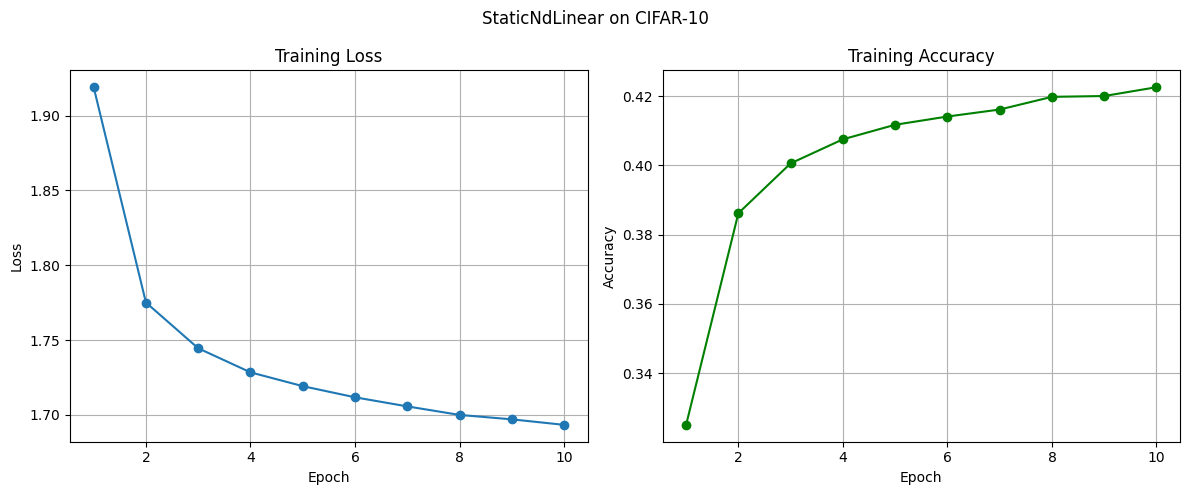


StaticNdLinear — Accuracy: 0.4174

Classification Report:
              precision    recall  f1-score   support

           0     0.4304    0.5320    0.4758      1000
           1     0.4819    0.4790    0.4804      1000
           2     0.3144    0.2490    0.2779      1000
           3     0.3082    0.2780    0.2923      1000
           4     0.3697    0.3630    0.3663      1000
           5     0.3238    0.3750    0.3475      1000
           6     0.4468    0.4950    0.4696      1000
           7     0.5264    0.4190    0.4666      1000
           8     0.4757    0.5490    0.5097      1000
           9     0.4954    0.4350    0.4633      1000

    accuracy                         0.4174     10000
   macro avg     0.4173    0.4174    0.4150     10000
weighted avg     0.4173    0.4174    0.4150     10000

Confusion Matrix:


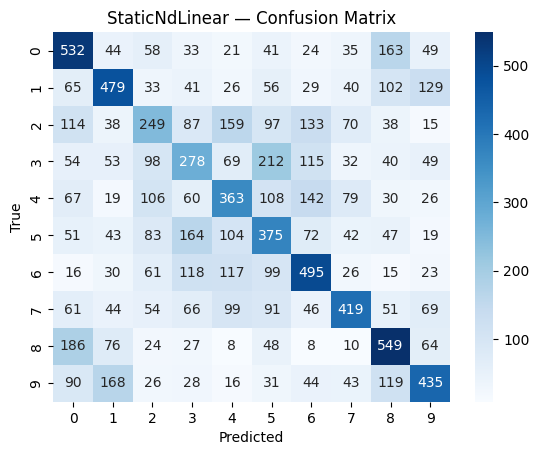

In [23]:

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, test_loader = get_cifar_dataloaders()

    model = StaticNdLinear(in_dims=(32, 96), out_dims=(32, 16), num_classes=10).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    losses, accs = [], []
    for epoch in range(1, 11):
        loss, acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        losses.append(loss)
        accs.append(acc)
        print(f"Epoch {epoch:2d} — Loss: {loss:.4f}, Acc: {acc:.4f}")

    plot_metrics(losses, accs, title="StaticNdLinear on CIFAR-10")
    evaluate_model(model, test_loader, device, model_name="StaticNdLinear")

if __name__ == "__main__":
    main()